In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\304690\Downloads\List of Countries by Sugarcane Production.csv")

In [3]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879


In [4]:
df.shape

(103, 7)

# Data Cleaning

In [5]:
#Replacing . with whitespace and , with .
df['Production (Tons)']=df['Production (Tons)'].str.replace('.','')
df['Production per Person (Kg)']=df['Production per Person (Kg)'].str.replace('.','').str.replace(',','.')
df['Acreage (Hectare)']=df['Acreage (Hectare)'].str.replace('.','')
df['Yield (Kg / Hectare)']=df['Yield (Kg / Hectare)'].str.replace('.','').str.replace(',','.')

In [6]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [7]:
#Renaming column
df.rename(columns={'Production (Tons)':'Production(Tons)','Production per Person (Kg)':'Production_per_Person','Acreage (Hectare)':'Acreage(Hectare)','Yield (Kg / Hectare)':'Yield(kg/Hectare'},inplace=True)

In [8]:
df

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person,Acreage(Hectare),Yield(kg/Hectare
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879
...,...,...,...,...,...,...,...
98,98,Lebanon,Asia,97,16,3,28386.4
99,99,Djibouti,Africa,53,51,NaN,NaN
100,100,Singapore,Asia,50,9,2,25
101,101,Samoa,Oceania,12,6,1,11949.8


In [9]:
#Checking null value
df.isnull().sum()

Unnamed: 0               0
Country                  0
Continent                0
Production(Tons)         0
Production_per_Person    0
Acreage(Hectare)         1
Yield(kg/Hectare         1
dtype: int64

In [10]:
df[df['Acreage(Hectare)'].isnull()]

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person,Acreage(Hectare),Yield(kg/Hectare
99,99,Djibouti,Africa,53,51,NaN,NaN


In [11]:
df=df.dropna().reset_index()
df

,index,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person,Acreage(Hectare),Yield(kg/Hectare
0,0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,4,Pakistan,Asia,65450704,324219,1130820,57879
...,...,...,...,...,...,...,...,...
97,97,97,Spain,Europe,394,8,9,43596.5
98,98,98,Lebanon,Asia,97,16,3,28386.4
99,100,100,Singapore,Asia,50,9,2,25
100,101,101,Samoa,Oceania,12,6,1,11949.8


In [12]:
df.drop(['Unnamed: 0','index'],inplace=True,axis=1)

In [13]:
df

,Country,Continent,Production(Tons),Production_per_Person,Acreage(Hectare),Yield(kg/Hectare
0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,India,Asia,348448000,260721,4950000,70393.5
2,China,Asia,123059739,88287,1675215,73459.1
3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,Pakistan,Asia,65450704,324219,1130820,57879
...,...,...,...,...,...,...
97,Spain,Europe,394,8,9,43596.5
98,Lebanon,Asia,97,16,3,28386.4
99,Singapore,Asia,50,9,2,25
100,Samoa,Oceania,12,6,1,11949.8


In [14]:
df.dtypes

Country                  object
Continent                object
Production(Tons)         object
Production_per_Person    object
Acreage(Hectare)         object
Yield(kg/Hectare         object
dtype: object

In [15]:
# Datatype Conversion
df['Yield(kg/Hectare']=df['Yield(kg/Hectare'].astype('float')
df['Production_per_Person']=df['Production_per_Person'].astype('float')
df['Production(Tons)']=df['Production(Tons)'].astype('float')
df['Acreage(Hectare)']=df['Acreage(Hectare)'].astype('float')
df.dtypes

Country                   object
Continent                 object
Production(Tons)         float64
Production_per_Person    float64
Acreage(Hectare)         float64
Yield(kg/Hectare         float64
dtype: object

In [16]:
df.nunique()

Country                  102
Continent                  6
Production(Tons)         102
Production_per_Person    101
Acreage(Hectare)         101
Yield(kg/Hectare         102
dtype: int64

In [17]:
# Checking Duplicacy
df.duplicated().sum()

0

# Univariate Analysis

In [18]:
df.head()

,Country,Continent,Production(Tons),Production_per_Person,Acreage(Hectare),Yield(kg/Hectare
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


# Q1) How many countries produce sugarcane from each continent

<Axes: xlabel='Continent'>

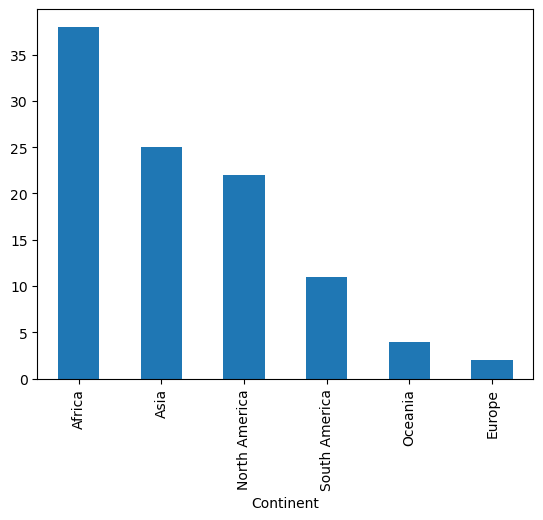

In [19]:
df['Continent'].value_counts().plot(kind='bar')

C:\Users\304690\AppData\Local\Temp\ipykernel_27156\2848997698.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Production(Tons)'])
C:\Users\304690\AppData\Local\Temp\ipykernel_27156\2848997698.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Production_per_Person'])
C:\Users\304690

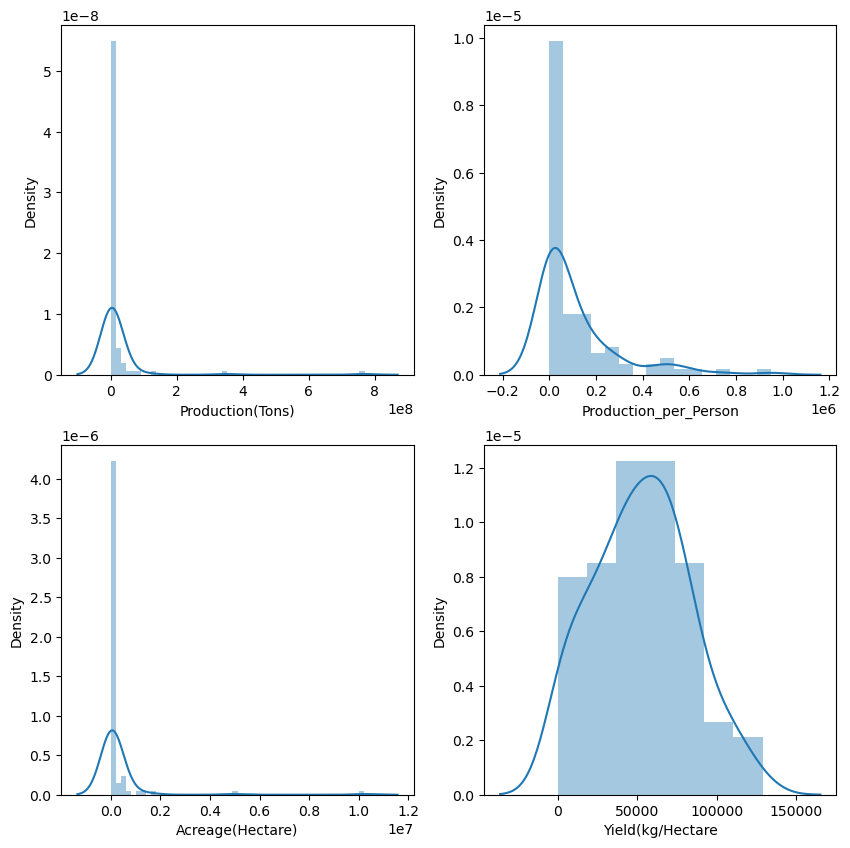

In [20]:
# Representing through distribution
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.distplot(df['Production(Tons)'])
plt.subplot(2,2,2)
sns.distplot(df['Production_per_Person'])
plt.subplot(2,2,3)
sns.distplot(df['Acreage(Hectare)'])
plt.subplot(2,2,4)
sns.distplot(df['Yield(kg/Hectare'])
plt.show()

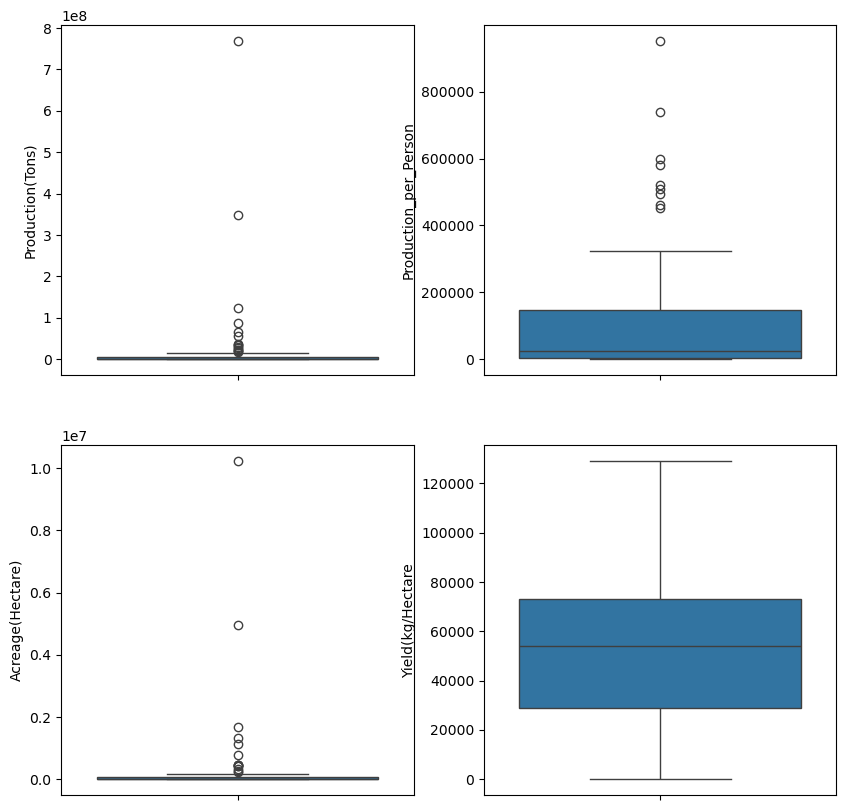

In [21]:
# Understanding the  outlier through Boxplot
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.boxplot(df['Production(Tons)'])
plt.subplot(2,2,2)
sns.boxplot(df['Production_per_Person'])
plt.subplot(2,2,3)
sns.boxplot(df['Acreage(Hectare)'])
plt.subplot(2,2,4)
sns.boxplot(df['Yield(kg/Hectare'])
plt.show()

In [22]:
df.describe()

,Production(Tons),Production_per_Person,Acreage(Hectare),Yield(kg/Hectare
count,1.020000e+02,102.000000,1.020000e+02,102.000000
mean,1.850372e+07,112952.435755,2.498981e+05,52628.078431
std,8.419149e+07,176651.341929,1.137003e+06,30504.676683
min,1.000000e+00,0.000000,0.000000e+00,10.000000
25%,6.251875e+04,3671.910000,1.104000e+03,29072.025000
50%,1.440044e+06,25572.500000,1.655800e+04,54108.950000
75%,6.426824e+06,146384.750000,8.047400e+04,73282.700000
max,7.686784e+08,951087.000000,1.022620e+07,129049.300000


# Bivariate analysis

In [23]:
df.head()

,Country,Continent,Production(Tons),Production_per_Person,Acreage(Hectare),Yield(kg/Hectare
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


# Q1) Which country produces maximum sugarcane

In [24]:
df_new=df[['Country','Production(Tons)']].set_index('Country')
df_new


,Production(Tons)
Country,
Brazil,768678382.0
India,348448000.0
China,123059739.0
Thailand,87468496.0
Pakistan,65450704.0
...,...
Spain,394.0
Lebanon,97.0
Singapore,50.0


In [25]:
df_new['Production(Tons)_percent']=(df_new['Production(Tons)']*100)/df_new['Production(Tons)'].sum()

In [26]:
df_new

,Production(Tons),Production(Tons)_percent
Country,,
Brazil,768678382.0,4.072729e+01
India,348448000.0,1.846200e+01
China,123059739.0,6.520138e+00
Thailand,87468496.0,4.634389e+00
Pakistan,65450704.0,3.467809e+00
...,...,...
Spain,394.0,2.087551e-05
Lebanon,97.0,5.139401e-06
Singapore,50.0,2.649176e-06


<Axes: xlabel='Country'>

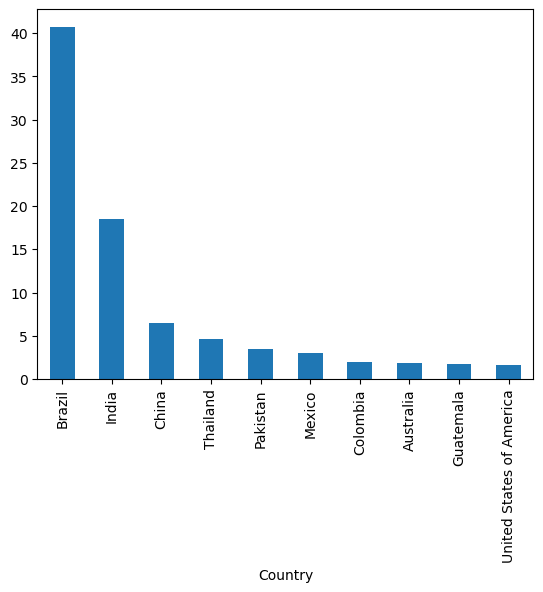

In [28]:
df_new['Production(Tons)_percent'].head(10).plot(kind='bar')

C:\Users\304690\AppData\Local\Temp\ipykernel_27156\2033838049.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


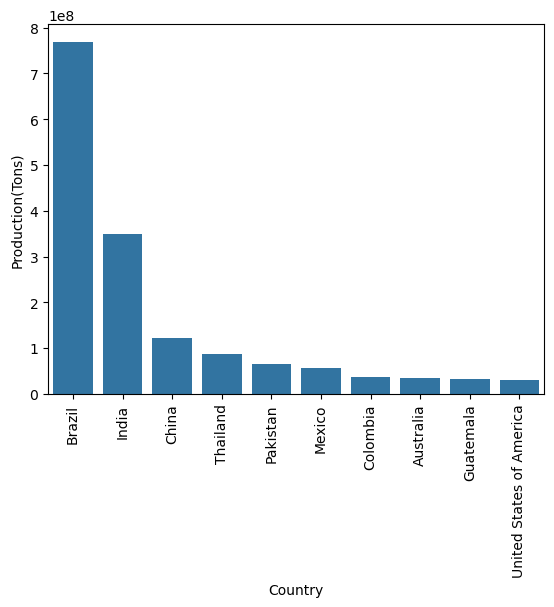

In [29]:
# Barplot 
ax=sns.barplot(data=df_new.head(10),x='Country',y='Production(Tons)')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
plt.show()

# Which country has highest land

In [30]:
df.head(10)

,Country,Continent,Production(Tons),Production_per_Person,Acreage(Hectare),Yield(kg/Hectare
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0
5,Mexico,North America,56446821.0,452524.000,781054.0,7227.0
6,Colombia,South America,36951213.0,740075.000,416626.0,88691.5
7,Australia,Oceania,34403004.0,1373.406,447204.0,76929.1
8,Guatemala,North America,33533403.0,1938.114,25985.0,129049.3
9,United States of America,North America,29926210.0,91304.000,37053.0,80766.0


C:\Users\304690\AppData\Local\Temp\ipykernel_27156\2159596498.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


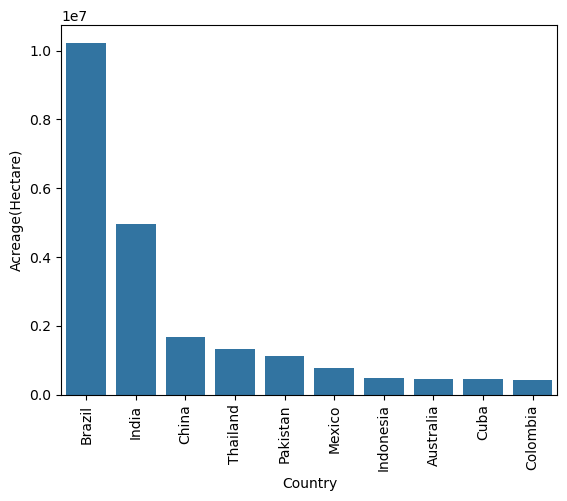

In [31]:
# Barplot 
df_acr=df.sort_values(by='Acreage(Hectare)',ascending=False)
ax=sns.barplot(data=df_acr.head(10),x='Country',y='Acreage(Hectare)')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
plt.show()

# which country has highest yield per hectare

C:\Users\304690\AppData\Local\Temp\ipykernel_27156\4214520326.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


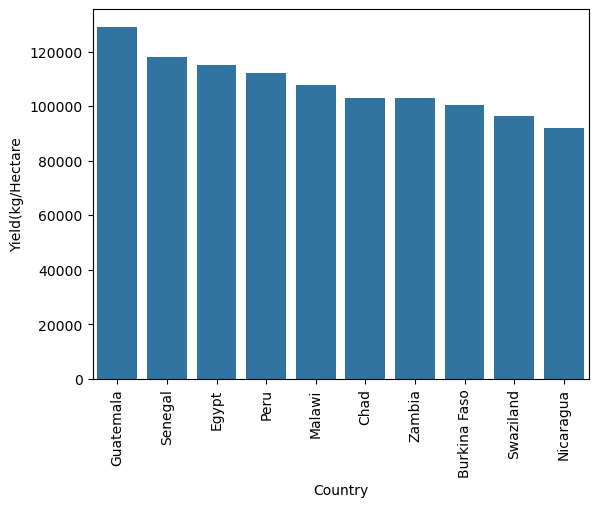

In [32]:
df_yield=df.sort_values(by='Yield(kg/Hectare',ascending=False)
ax=sns.barplot(data=df_yield.head(10),x='Country',y='Yield(kg/Hectare')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
plt.show()

# Which country has highest production

C:\Users\304690\AppData\Local\Temp\ipykernel_27156\2801629704.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


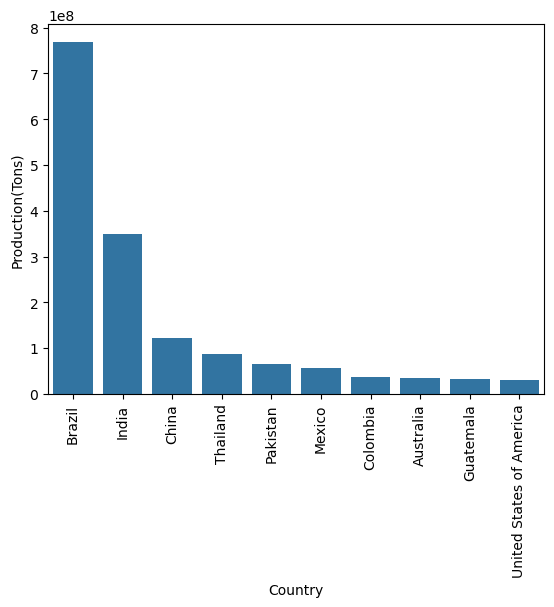

In [33]:
df_pro=df.sort_values(by='Production(Tons)',ascending=False)
ax=sns.barplot(data=df_pro.head(10),x='Country',y='Production(Tons)')
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
plt.show()

# Correaltion

In [34]:
df.corr(numeric_only=True)

,Production(Tons),Production_per_Person,Acreage(Hectare),Yield(kg/Hectare
Production(Tons),1.000000,0.015000,0.997550,0.132812
Production_per_Person,0.015000,1.000000,0.012557,0.017999
Acreage(Hectare),0.997550,0.012557,1.000000,0.113433
Yield(kg/Hectare,0.132812,0.017999,0.113433,1.000000


<Axes: >

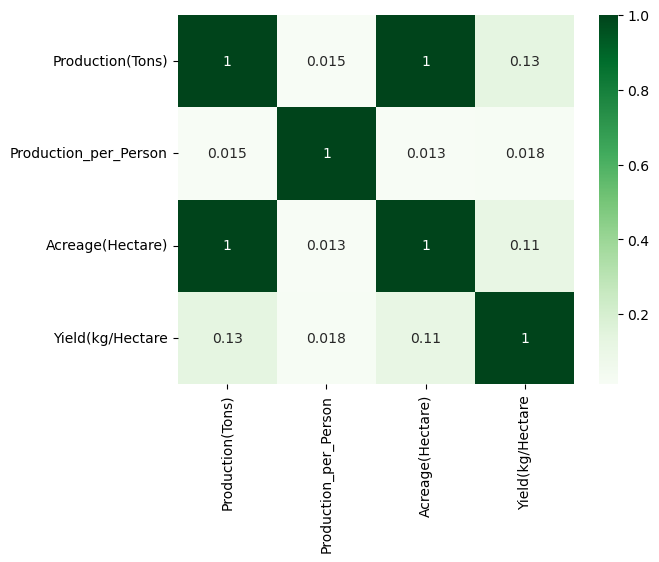

In [35]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='Greens')

# Do country has highest land will produce more sugarcane

<Axes: xlabel='Acreage(Hectare)', ylabel='Production(Tons)'>

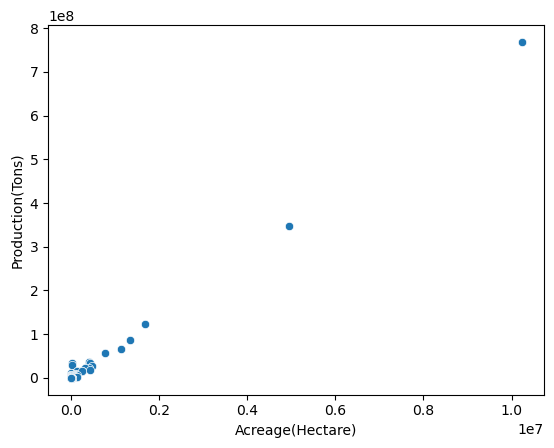

In [42]:
sns.scatterplot(data=df,x='Acreage(Hectare)',y='Production(Tons)')

# Do country which yield more suagrcane per hectare produce more sugarcane in total

<Axes: xlabel='Yield(kg/Hectare', ylabel='Production(Tons)'>

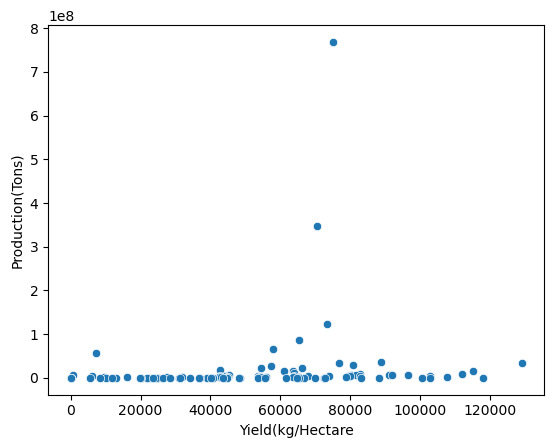

In [37]:
sns.scatterplot(data=df,x='Yield(kg/Hectare',y='Production(Tons)')

# Analysis the continent

In [54]:
df_continent = df.groupby("Continent").sum()


In [56]:
df_continent["number_of_countries"] = df.groupby("Continent").count()["Country"]


In [57]:
df_continent

,Country,Production(Tons),Production_per_Person,Acreage(Hectare),Yield(kg/Hectare,number_of_countries
Continent,,,,,,
Africa,EgyptSouth AfricaKenyaSwazilandSudanZambiaMaur...,89681472.0,2332636.293,1439089.0,2142107.5,38
Asia,IndiaChinaThailandPakistanIndonesiaPhilippines...,721930425.0,1857769.303,10608319.0,1171871.4,25
Europe,PortugalSpain,5823.0,536.000,71.0,131870.9,2
North America,MexicoGuatemalaUnited States of AmericaCubaEl ...,173995947.0,3796081.508,1581983.0,1082602.4,22
Oceania,AustraliaFijiPapua New GuineaSamoa,36177574.0,28593.605,490909.0,162419.1,4
South America,BrazilColombiaArgentinaPeruEcuadorBoliviaParag...,865588126.0,3505531.738,11369236.0,677192.7,11


# Which continent produce maximum sugarcane

<Axes: xlabel='Continent'>

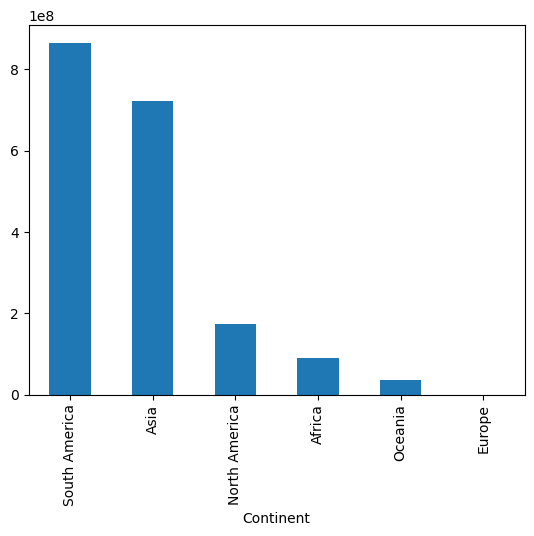

In [58]:
df_continent["Production(Tons)"].sort_values(ascending =  False).plot(kind = "bar")


## Do number of countries in continent effect the production of sugarcane?

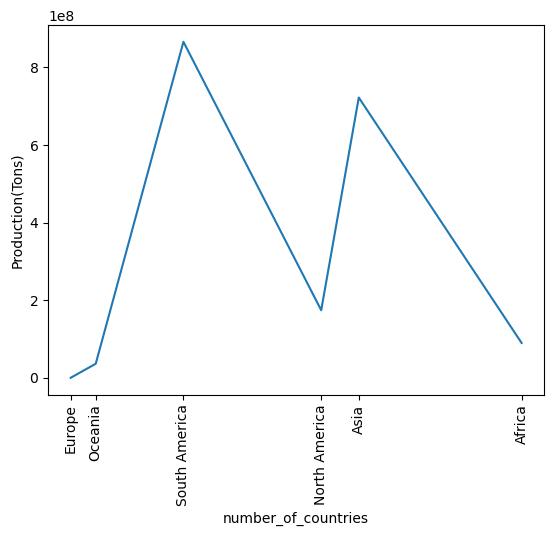

In [59]:
continent_names = df_continent.index.to_list()
sns.lineplot(data = df_continent,x = "number_of_countries", y= "Production(Tons)" )
plt.xticks(df_continent["number_of_countries"], continent_names, rotation =90)
plt.show()


## Do continent with highest land produces more sugarcane?

<Axes: xlabel='Acreage(Hectare)', ylabel='Production(Tons)'>

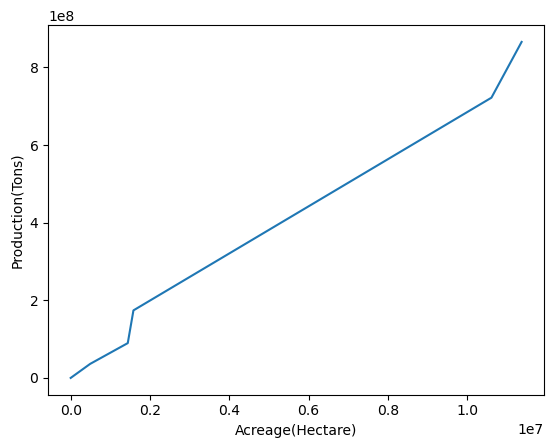

In [61]:
sns.lineplot(data = df_continent,x = "Acreage(Hectare)", y= "Production(Tons)" )


## Production distribution by continent

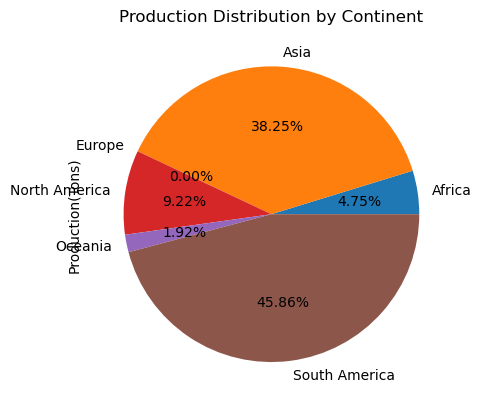

In [63]:
df_continent["Production(Tons)"].plot(kind = "pie", autopct = "%.2f%%")
plt.title('Production Distribution by Continent')
plt.show()


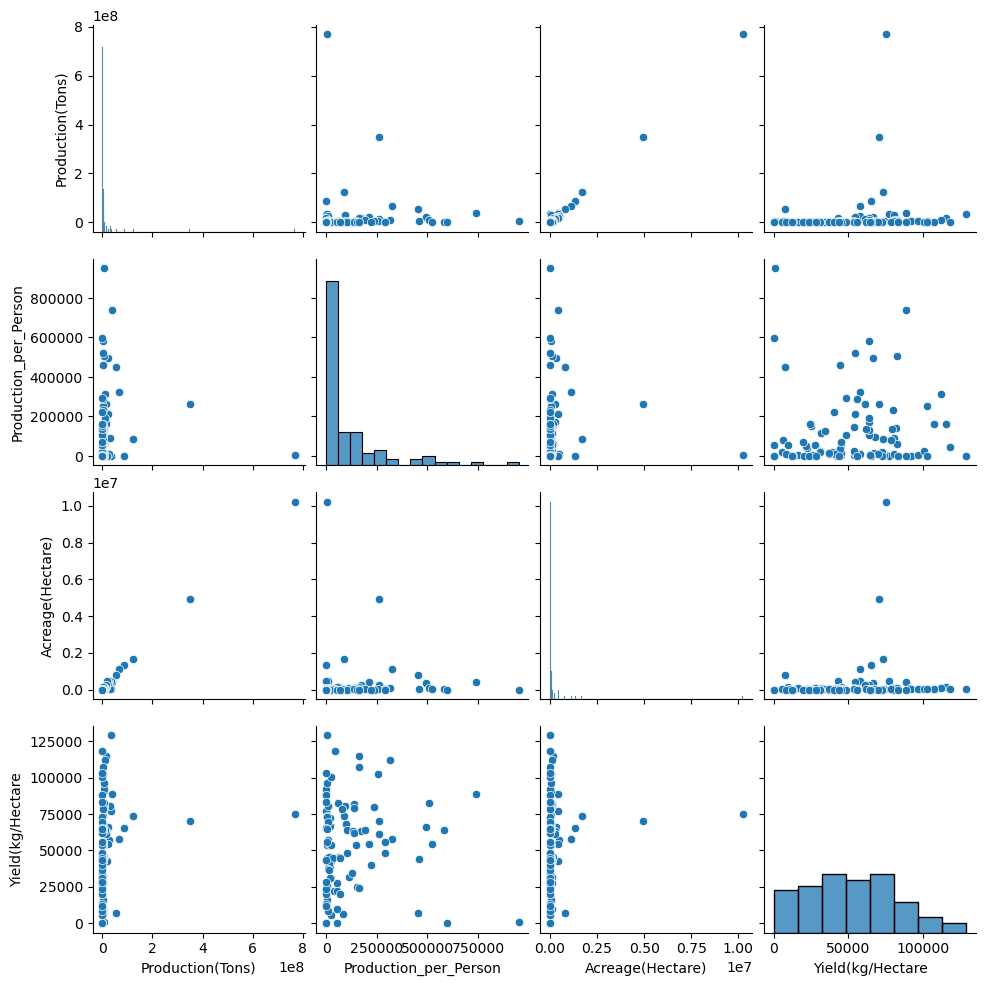

In [65]:
# In addition understanding all the graph in one go
sns.pairplot(df)